# Telco Customer Churn — Threshold Tuning & Business Impact

Цель ноутбука:

- перейти от "сырых" вероятностей churn к конкретным действиям;
- подобрать пороги классификации под разные бизнес-сценарии;
- оценить, сколько клиентов попадает в retention-кампанию при разных порогах;
- понять, сколько churn-клиентов мы успеваем "поймать" в каждом сценарии.


In [14]:
import pandas as pd
import numpy as np

from catboost import CatBoostClassifier, Pool

from sklearn.metrics import (
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    classification_report,
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)


In [15]:
TARGET_COL = "churn_value"

train = pd.read_csv("../data/processed/train.csv")
valid = pd.read_csv("../data/processed/valid.csv")
test  = pd.read_csv("../data/processed/test.csv")

X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]

X_valid = valid.drop(columns=[TARGET_COL])
y_valid = valid[TARGET_COL]

X_test  = test.drop(columns=[TARGET_COL])
y_test  = test[TARGET_COL]

X_train.shape, X_valid.shape, X_test.shape


((4225, 24), (1409, 24), (1409, 24))

In [16]:
num_features = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

num_features, cat_features


(['tenure_months',
  'monthly_charges',
  'total_charges',
  'is_new_customer',
  'is_long_contract',
  'has_internet',
  'num_addon_services',
  'avg_monthly_revenue'],
 ['gender',
  'senior_citizen',
  'partner',
  'dependents',
  'phone_service',
  'multiple_lines',
  'internet_service',
  'online_security',
  'online_backup',
  'device_protection',
  'tech_support',
  'streaming_tv',
  'streaming_movies',
  'contract',
  'paperless_billing',
  'payment_method'])

В предыдущем ноутбуке (`04_modeling_catboost_shap.ipynb`) была обучена модель CatBoost
и показано, что она даёт качественный baseline по ROC-AUC и PR-AUC.

Здесь для воспроизводимости мы переобучим ту же модель с теми же гиперпараметрами
(на train + valid в качестве eval_set), а затем используем её вероятности
для анализа порогов и бизнес-сценариев.


In [17]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features
)

valid_pool = Pool(
    data=X_valid,
    label=y_valid,
    cat_features=cat_features
)

cat_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    depth=6,
    learning_rate=0.1,
    n_estimators=500,
    random_seed=RANDOM_STATE,
    class_weights=[1.0, 3.0],
    verbose=100,
    use_best_model=True,
    train_dir="../logs/notebook_05_thresholds"
)


cat_model.fit(
    train_pool,
    eval_set=valid_pool,
    verbose=100
)


0:	test: 0.8197473	best: 0.8197473 (0)	total: 26.9ms	remaining: 13.4s
100:	test: 0.8545493	best: 0.8556524 (52)	total: 2.88s	remaining: 11.4s
200:	test: 0.8496370	best: 0.8556524 (52)	total: 6.06s	remaining: 9.01s
300:	test: 0.8477150	best: 0.8556524 (52)	total: 9.23s	remaining: 6.1s
400:	test: 0.8455579	best: 0.8556524 (52)	total: 12.5s	remaining: 3.09s
499:	test: 0.8444922	best: 0.8556524 (52)	total: 15.8s	remaining: 0us

bestTest = 0.8556524323
bestIteration = 52

Shrink model to first 53 iterations.


Модель CatBoost обучалась с использованием валидационного набора и флага
`use_best_model=True`. По ходу обучения:

- лучшая метрика AUC на валидации достигается на **52-й итерации**
  (`bestTest ≈ 0.856`, `bestIteration = 52`);
- после этого качество на валидации начинает постепенно ухудшаться,
  поэтому CatBoost автоматически **усекает ансамбль до первых 53 деревьев**.

Таким образом, переобучение контролируется встроенным early stopping,
а финальная модель представляет собой "лучшую" конфигурацию по валидации,
а не просто последние 500 итераций.


In [18]:
def evaluate_cat_model(model, X, y, name="model"):
    proba = model.predict_proba(X)[:, 1]
    roc = roc_auc_score(y, proba)
    pr  = average_precision_score(y, proba)
    print(f"{name:25s} | ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")
    return {"model": name, "roc_auc": roc, "pr_auc": pr}

res_train = evaluate_cat_model(cat_model, X_train, y_train, "CatBoost (train)")
res_valid = evaluate_cat_model(cat_model, X_valid, y_valid, "CatBoost (valid)")
res_test  = evaluate_cat_model(cat_model, X_test,  y_test,  "CatBoost (test)")

res_train, res_valid, res_test


CatBoost (train)          | ROC-AUC: 0.8836 | PR-AUC: 0.7228
CatBoost (valid)          | ROC-AUC: 0.8557 | PR-AUC: 0.6744
CatBoost (test)           | ROC-AUC: 0.8543 | PR-AUC: 0.6778


({'model': 'CatBoost (train)',
  'roc_auc': 0.883575737789345,
  'pr_auc': 0.7228012652113257},
 {'model': 'CatBoost (valid)',
  'roc_auc': 0.8556524322508977,
  'pr_auc': 0.6744450796957855},
 {'model': 'CatBoost (test)',
  'roc_auc': 0.8543374925727867,
  'pr_auc': 0.6778226218112724})

Модель CatBoost показывает стабильное качество на всех выборках:

- **Train:** ROC-AUC ≈ 0.884, PR-AUC ≈ 0.723  
- **Validation:** ROC-AUC ≈ 0.856, PR-AUC ≈ 0.674  
- **Test:** ROC-AUC ≈ 0.854, PR-AUC ≈ 0.678  

Разница между train и valid/test умеренная, признаков сильного переобучения нет.
Качество на тесте очень близко к валидации, что подтверждает хорошую
обобщающую способность модели.

По сравнению с baseline-моделями из ноутбука `03_modeling_baselines`
CatBoost даёт:

- сопоставимый ROC-AUC;
- немного более высокий PR-AUC (важно для редкого класса churn),
  то есть лучше выделяет churn-клиентов среди всех "подсвеченных" моделью.


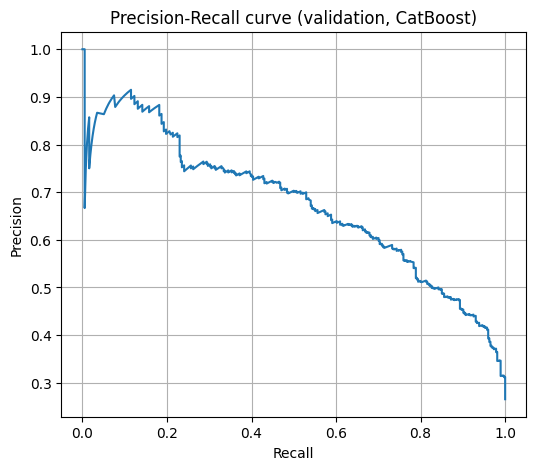

In [19]:
# вероятности на валидации
proba_valid = cat_model.predict_proba(X_valid)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_valid, proba_valid)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve (validation, CatBoost)")
plt.grid(True)
plt.show()


Precision–Recall кривая на валидации показывает типичный trade-off:

- при **низком recall** (слева) модель может достигать очень высокой precision
  — но при этом "видит" только небольшую часть churn-клиентов;
- по мере роста recall (движение вправо) precision постепенно падает —
  мы охватываем больше churn-клиентов, но среди отобранных становится
  больше "лишних" пользователей.

Именно из этой кривой логично выбирать порог классификации в зависимости от того,
что важнее бизнесу: **максимально поймать churn** или **минимизировать
лишние контакты**.


In [ ]:
def threshold_metrics(y_true, proba, thresholds):
    rows = []
    total = len(y_true)
    total_positives = y_true.sum()  # всего churn-клиентов

    for thr in thresholds:
        y_pred = (proba >= thr).astype(int)

        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()

        predicted_positives = (y_pred == 1).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

        share_flagged = predicted_positives / total  # доля клиентов, попавших в кампанию

        rows.append({
            "threshold": thr,
            "precision": precision,
            "recall": recall,
            "f1": 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0,
            "flagged_customers": predicted_positives,
            "flagged_share": share_flagged,
            "caught_churn": tp,
            "total_churn": int(total_positives),
            "recall_churn": recall
        })

    return pd.DataFrame(rows).sort_values("threshold", ascending=False)


In [21]:
thresholds_to_check = np.round(np.linspace(0.1, 0.9, 9), 2)
metrics_df = threshold_metrics(y_valid, proba_valid, thresholds_to_check)
metrics_df


,threshold,precision,recall,f1,flagged_customers,flagged_share,caught_churn,total_churn,recall_churn
8,0.9000,0.9130,0.1123,0.2000,46,0.0326,42,374,0.1123
7,0.8000,0.7436,0.3877,0.5097,195,0.1384,145,374,0.3877
6,0.7000,0.6333,0.6096,0.6213,360,0.2555,228,374,0.6096
5,0.6000,0.5842,0.7326,0.6501,469,0.3329,274,374,0.7326
4,0.5000,0.5127,0.8075,0.6272,589,0.4180,302,374,0.8075
3,0.4000,0.4757,0.8904,0.6201,700,0.4968,333,374,0.8904
2,0.3000,0.4328,0.9305,0.5908,804,0.5706,348,374,0.9305
1,0.2000,0.3849,0.9652,0.5503,938,0.6657,361,374,0.9652
0,0.1000,0.3539,0.9813,0.5202,1037,0.7360,367,374,0.9813


Таблица показывает, как меняются метрики при разных порогах:

- **низкие пороги (0.1–0.2)**  
  - в кампанию попадает от ~66% до 74% всей базы (`flagged_share` 0.66–0.74);
  - recall по churn очень высокий (0.96–0.98) — модель успевает "подсветить"
    почти всех клиентов, которые уйдут;
  - precision при этом низкий (0.35–0.38) — среди отобранных много тех,
    кто останется.

- **средние пороги (0.4–0.6)**  
  - доля базы в кампании снижается до 33–50%;
  - precision растёт до 0.48–0.58;
  - recall остаётся высоким (0.73–0.89);
  - F1-мера максимальна примерно на пороге **0.6** (`f1 ≈ 0.65`).

- **высокие пороги (0.8–0.9)**  
  - в кампанию попадает только 3–14% клиентов;
  - precision очень высокий (0.74–0.91);
  - но recall сильно падает (0.11–0.39) — мы теряем большинство churn-клиентов.

Это иллюстрирует типичный выбор:
или **массовая кампания с большим охватом churn**,
или **узкий таргет с высокой точностью**, либо компромисс между ними.


In [22]:
df = metrics_df.copy()

# агрессивный сценарий: высокий recall
aggressive = (
    df[df["recall"] >= 0.8]
    .sort_values(["recall", "precision"], ascending=[False, False])
    .head(1)
)

# сбалансированный сценарий: максимум F1
balanced = df.sort_values("f1", ascending=False).head(1)

# консервативный сценарий: максимум precision при ограничении доли кампании
conservative = (
    df[df["flagged_share"] <= 0.2]
    .sort_values("precision", ascending=False)
    .head(1)
)

scenarios = pd.concat(
    [
        aggressive.assign(scenario="aggressive"),
        balanced.assign(scenario="balanced"),
        conservative.assign(scenario="conservative"),
    ],
    ignore_index=True
)

scenarios


,threshold,precision,recall,f1,flagged_customers,flagged_share,caught_churn,total_churn,recall_churn,scenario
0,0.1000,0.3539,0.9813,0.5202,1037,0.7360,367,374,0.9813,aggressive
1,0.6000,0.5842,0.7326,0.6501,469,0.3329,274,374,0.7326,balanced
2,0.9000,0.9130,0.1123,0.2000,46,0.0326,42,374,0.1123,conservative


### Сценарии применения модели

На основе таблицы метрик выделены три сценария:

1. **Aggressive (порог 0.10)**  
   - в кампанию попадает ~74% базы (`flagged_share ≈ 0.74`);
   - recall по churn ≈ **0.98** — модель практически не пропускает
     клиентов с высоким риском ухода;
   - precision ≈ **0.35** — то есть примерно каждый третий "подсвеченный"
     действительно уйдёт.  
   Такой сценарий подходит, если коммуникация дешевая (email, пуш-уведомления)
   и бизнес готов охватывать очень широкий сегмент.

2. **Balanced (порог 0.60)**  
   - доля базы в кампании ≈ **33%**;
   - precision ≈ **0.58**, recall ≈ **0.73**, максимальная F1-мера (≈0.65);
   - это хороший "рабочий" компромисс между покрытием churn-клиентов
     и количеством лишних контактов.

3. **Conservative (порог 0.90)**  
   - в кампанию попадает только ~3% клиентов;
   - precision ≈ **0.91** — почти все отобранные действительно уйдут;
   - но recall лишь ≈ **0.11** — модель "видит" только небольшую часть churn.  
   Такой режим имеет смысл, когда удержание дорого (персональные звонки,
   серьёзные скидки) и бизнесу важно минимизировать число лишних обращений.


In [23]:
best_balanced_thr = float(balanced["threshold"].iloc[0])
best_balanced_thr


0.6

In [24]:
proba_test = cat_model.predict_proba(X_test)[:, 1]
y_test_pred_balanced = (proba_test >= best_balanced_thr).astype(int)

print(f"Threshold (balanced): {best_balanced_thr:.2f}")
print(classification_report(y_test, y_test_pred_balanced, digits=4))


Threshold (balanced): 0.60
              precision    recall  f1-score   support

           0     0.8873    0.7913    0.8366      1035
           1     0.5556    0.7219    0.6279       374

    accuracy                         0.7729      1409
   macro avg     0.7214    0.7566    0.7322      1409
weighted avg     0.7993    0.7729    0.7812      1409



## Итоги: пороги и бизнес-эффект

- CatBoost-модель даёт устойчивое качество на тестовой выборке
  (ROC-AUC ≈ 0.854, PR-AUC ≈ 0.678) и хорошо отделяет клиентов с высоким
  риском churn от лояльной базы.
- Анализ порогов показывает, что:
  - при агрессивном пороге 0.10 можно "подсветить" до **98%** churn-клиентов,
    но придётся коммуницировать с ~74% всей базы;
  - при консервативном пороге 0.90 в кампанию попадает всего ~3% клиентов
    с precision ≈ 0.91, но мы видим лишь ~11% всех churn-клиентов;
  - **сбалансированный порог 0.60** даёт разумный компромисс:
    кампания охватывает ~33% базы, при этом recall по churn ≈ 0.73,
    а precision ≈ 0.58.

С точки зрения продукта:

- модель предоставляет **ранжирование клиентов по вероятности churn**;
- бизнес может выбирать порог в зависимости от:
  - бюджета на удержание,
  - стоимости контакта,
  - ожидаемой ценности сохранённого клиента (LTV);
- модель не навязывает один "правильный" порог, а даёт инструмент
  для настройки разных сценариев retention-кампаний.

Таким образом, ML-модель churn превращается из "просто предсказателя"
в практический инструмент для планирования и приоритизации работы
с клиентской базой.
